# Multiple Linear Regression

In [1]:
# Load California housing dataset

from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()


In [2]:
X = california.data
y = california.target


In [3]:
import pandas as pd

df = pd.DataFrame(X, columns=california.feature_names)
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)


In [5]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(16512, 8) (4128, 8) (16512,) (4128,)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print("Sklearn Model Coefficients:", model.coef_)
print("Sklearn Model Intercept:", model.intercept_)


Sklearn Model Coefficients: [ 4.33481147e-01  9.13203774e-03 -1.00206297e-01  6.11611814e-01
 -5.80927065e-06 -3.41460825e-03 -4.26281098e-01 -4.41029824e-01]
Sklearn Model Intercept: -37.52785391522627


In [8]:
# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate model on training set
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("Sklearn Model Train MSE:", mse_train)
print("Sklearn Model Train R2 Score:", r2_train)


Sklearn Model Train MSE: 0.5229180518054783
Sklearn Model Train R2 Score: 0.6061334059992144


In [10]:
# Evaluate model on test set
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Sklearn Model Test MSE:", mse_test)
print("Sklearn Model Test R2 Score:", r2_test)


Sklearn Model Test MSE: 0.5304460892018628
Sklearn Model Test R2 Score: 0.605787292569561


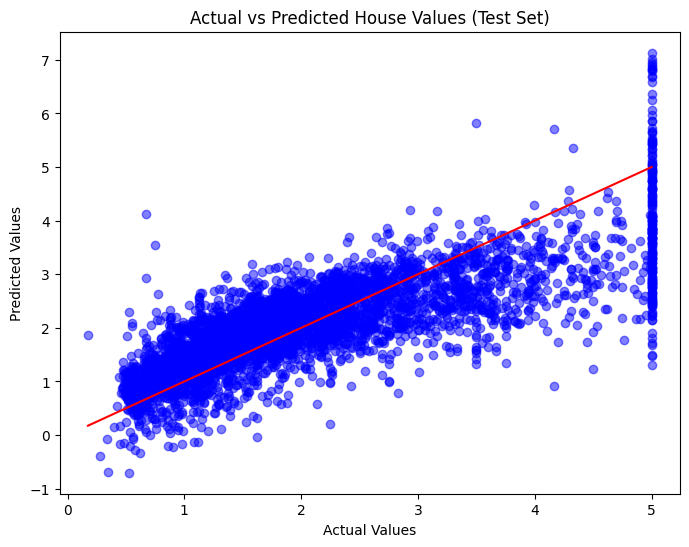

In [11]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted (Test set)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values (Test Set)")
plt.show()
